In [1]:
from stepmix.stepmix import StepMix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
cluster_df = pd.read_csv("../../data/master_data/2016_to_2023_clustering_input_data.csv")

len(cluster_df)

85659

In [3]:
cluster_cols = ["Age9",
                "Gend3",
                "Eth7",
                "Disab2_POP",
                "Educ6",
                "NSSEC5",
                "IMD10",
                "WorkStat8",
                "Child4",
                "HHLiv9",
                "Motiva_POP",
                "motivd_POP"]

X = cluster_df[cluster_cols]

X.head()

,Age9,Gend3,Eth7,Disab2_POP,Educ6,NSSEC5,IMD10,WorkStat8,Child4,HHLiv9,Motiva_POP,motivd_POP
0,0,0,3,1,0,0,1,1,1,2,0,3
1,2,0,3,1,0,1,3,1,0,1,1,3
2,2,1,0,1,0,0,6,0,0,0,1,3
3,2,0,1,1,0,0,3,0,1,4,1,3
4,2,1,1,0,0,0,3,1,1,4,0,2


In [12]:
results = []

for k in range(24, 29):

    try:
    
        print(f"Fitting {k} classes...")

        model = StepMix(n_components=k,  measurement="categorical", random_state=42, n_init=10, max_iter=1000, abs_tol=1e-5)

        model.fit(X)

        post = model.predict_proba(X)

        entropy = 1 + np.sum(post * np.log(post + 1e-12)) / (len(X) * np.log(k))

        proportions = post.mean(axis=0)

        assignment = post.max(axis=1)

        results.append({"Classes": k,
                        "LogLik": model.score(X) * len(X),
                        "AIC": model.aic(X),
                        "BIC": model.bic(X),
                        "Entropy": entropy,
                        "Converged": model.converged_,
                        "Iterations": model.n_iter_,
                        "MinClass": proportions.min(),
                        "MaxClass": proportions.max(),
                        "MeanAssignment": assignment.mean(),
                        "MedianAssignment": np.median(assignment)})
        
    except Exception as e:
        results.append({"Classes": k, "Error": str(e)})

    pd.DataFrame(results).to_csv("latent_class_analysis_results.csv", index=False)

Fitting 24 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 10/10 [07:36<00:00, 45.65s/it, max_LL=-1.15e+6, max_avg_LL=-13.5]


Fitting 25 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 10/10 [06:49<00:00, 41.00s/it, max_LL=-1.15e+6, max_avg_LL=-13.5]


Fitting 26 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 10/10 [06:41<00:00, 40.17s/it, max_LL=-1.15e+6, max_avg_LL=-13.5]


Fitting 27 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 10/10 [07:40<00:00, 46.03s/it, max_LL=-1.15e+6, max_avg_LL=-13.5]


Fitting 28 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 10/10 [07:15<00:00, 43.59s/it, max_LL=-1.15e+6, max_avg_LL=-13.5]


In [13]:
results_df = pd.DataFrame(results)

print(results_df)

   Classes        LogLik           AIC           BIC   Entropy  Converged  \
0       24 -1.154026e+06  2.310979e+06  2.324670e+06  0.815758       True   
1       25 -1.153821e+06  2.310691e+06  2.324952e+06  0.811395       True   
2       26 -1.153403e+06  2.309976e+06  2.324808e+06  0.795373       True   
3       27 -1.152883e+06  2.309058e+06  2.324461e+06  0.808665       True   
4       28 -1.152374e+06  2.308161e+06  2.324136e+06  0.801640       True   

   Iterations  MinClass  MaxClass  MeanAssignment  MedianAssignment  
0         228  0.006293  0.104320        0.767623          0.811638  
1         224  0.007219  0.103764        0.771242          0.815371  
2         107  0.006339  0.092043        0.743452          0.757991  
3         185  0.005797  0.101882        0.757504          0.796262  
4         281  0.004037  0.079220        0.746739          0.770802  


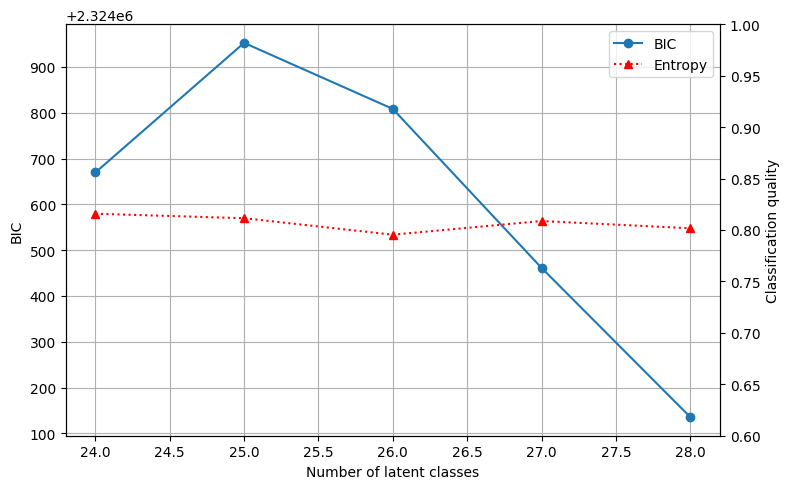

In [14]:
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(results_df["Classes"],
         results_df["BIC"],
         marker="o",
         label="BIC")

ax1.set_xlabel("Number of latent classes")
ax1.set_ylabel("BIC")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(results_df["Classes"],
         results_df["Entropy"],
         marker="^",
         linestyle=":",
         color = "red",
         label="Entropy")

ax2.set_ylabel("Classification quality")
ax2.set_ylim(0.6, 1.0)

lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="best")

plt.tight_layout()
plt.show()